<a href="https://colab.research.google.com/github/rubenmedinna/ProyectoPPE/blob/main/ProyectoVision6F_23310374_23310341.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 118.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="2FHnvpxgaEhrpBcGb8x3")
project = rf.workspace("oakdev").project("vest-pbrbu")
version = project.version(3)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vest-3 in yolov11:: 100%|██████████| 6338/6338 [00:01<00:00, 4569.96it/s]


In [3]:
from ultralytics import YOLO
model=YOLO("yolo11s.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
data_path = "/content/vest-3/data.yaml"
results = model.train(data=data_path,
                      epochs=15,
                      imgsz=640)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vest-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

In [5]:
#Cargamos el modelo ya entrenado
custom_model=YOLO("/content/runs/detect/train/weights/best.pt")

In [7]:
#Realizamos predicciones
res = custom_model ("/content/vest-3/test/images")


image 1/122 /content/vest-3/test/images/00001_jpg.rf.ff3a88f61968503b6825483a807a85e0.jpg: 640x640 1 Vest, 15.5ms
image 2/122 /content/vest-3/test/images/00011_jpg.rf.cb1eede95499caff730719dc7a5662a0.jpg: 640x640 3 No-Helmets, 2 Vests, 15.5ms
image 3/122 /content/vest-3/test/images/00035_jpg.rf.03ab036d30f50d77348a9b4dc038fc5b.jpg: 640x640 2 No-Helmets, 1 Vest, 15.5ms
image 4/122 /content/vest-3/test/images/00039_jpg.rf.b902f0df348a54c5503cd613e26b5ee3.jpg: 640x640 2 Vests, 15.5ms
image 5/122 /content/vest-3/test/images/00052_jpg.rf.1df0f4dbd85dba42fd9ed4d9a73fa08c.jpg: 640x640 1 No-Helmet, 15.5ms
image 6/122 /content/vest-3/test/images/00077_jpg.rf.950eb6b48659aea79e0730fa54782615.jpg: 640x640 3 Vests, 15.5ms
image 7/122 /content/vest-3/test/images/00105_jpg.rf.216a64bd026a0ea80ed809877b02c9d4.jpg: 640x640 5 No-Helmets, 5 Vests, 15.5ms
image 8/122 /content/vest-3/test/images/00118_jpg.rf.d55663b05e782318f6555cf01666e7aa.jpg: 640x640 1 Vest, 15.5ms
image 9/122 /content/vest-3/test/ima

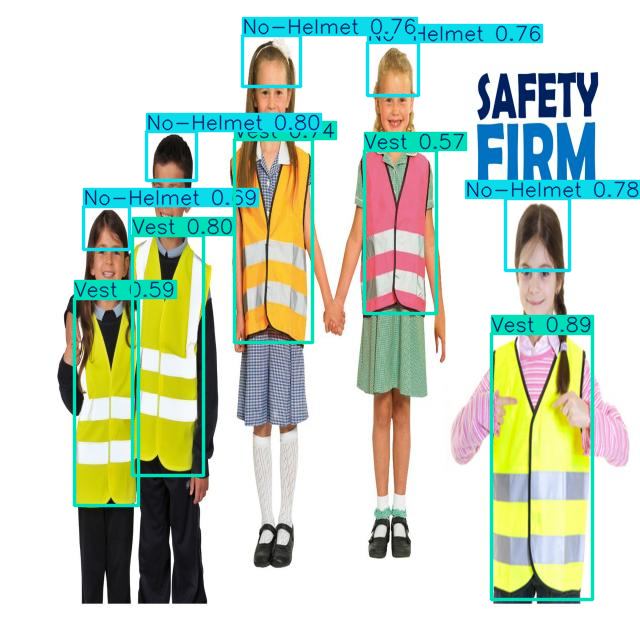

In [11]:
res[6].show()